**IMPORT NECCESSORY LIBRARY**

In [29]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**READ THE GIVEN DATA**

In [30]:
data=pd.read_csv('/content/tweet_emotions.csv')

In [31]:
data.head()
df=data.copy()

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   content    40000 non-null  object
dtypes: int64(1), object(2)
memory usage: 937.6+ KB


In [33]:
display(data['tweet_id'].value_counts().sum())

np.int64(40000)

We can drop tweet_id column.it is not need for modelling

In [34]:
data=data.drop('tweet_id',axis=1)

In [35]:
data.head()

,sentiment,content
0,empty,@tiffanylue i know i was listenin to bad habi...
1,sadness,Layin n bed with a headache ughhhh...waitin o...
2,sadness,Funeral ceremony...gloomy friday...
3,enthusiasm,wants to hang out with friends SOON!
4,neutral,@dannycastillo We want to trade with someone w...


# PREPROCESSING THE DATA


HERE CONTENT COLUMN IS THE INPUT AND SENTIMENT IS THE LABEL ,WE NEED TO LABEL ENCODE TARGET COLUMN FIRST

In [36]:
data.dtypes

,0
sentiment,object
content,object


In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
data['sentiment_encoded'] = label_encoder.fit_transform(data['sentiment'])

# find class wieght

In [38]:
data.head()

,sentiment,content,sentiment_encoded
0,empty,@tiffanylue i know i was listenin to bad habi...,2
1,sadness,Layin n bed with a headache ughhhh...waitin o...,10
2,sadness,Funeral ceremony...gloomy friday...,10
3,enthusiasm,wants to hang out with friends SOON!,3
4,neutral,@dannycastillo We want to trade with someone w...,8


In [39]:
sentiment_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
display(sentiment_mapping)


{'anger': np.int64(0),
 'boredom': np.int64(1),
 'empty': np.int64(2),
 'enthusiasm': np.int64(3),
 'fun': np.int64(4),
 'happiness': np.int64(5),
 'hate': np.int64(6),
 'love': np.int64(7),
 'neutral': np.int64(8),
 'relief': np.int64(9),
 'sadness': np.int64(10),
 'surprise': np.int64(11),
 'worry': np.int64(12)}

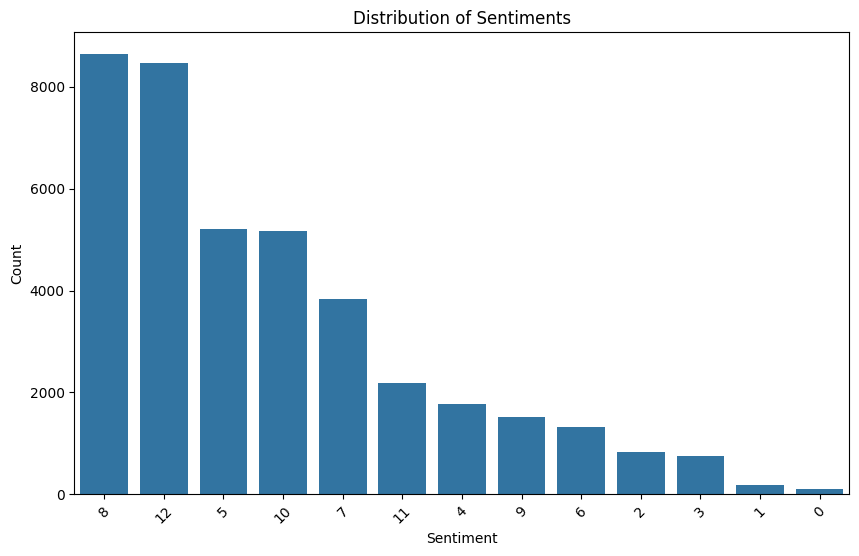

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment_encoded', data=data, order = data['sentiment_encoded'].value_counts().index)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Due to imbalance adjust class weights**



In [41]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(data['sentiment_encoded']),
    y=data['sentiment_encoded']
)

# Create a dictionary of class weights
class_weight_dict = dict(zip(np.unique(data['sentiment_encoded']), class_weights))

display("Class Weights:", class_weight_dict)

'Class Weights:'

{np.int64(0): np.float64(27.972027972027973),
 np.int64(1): np.float64(17.189514396218307),
 np.int64(2): np.float64(3.7205841317086783),
 np.int64(3): np.float64(4.053917097395359),
 np.int64(4): np.float64(1.7325017325017324),
 np.int64(5): np.float64(0.5906936219856166),
 np.int64(6): np.float64(2.3257166114308974),
 np.int64(7): np.float64(0.8008649341288592),
 np.int64(8): np.float64(0.3562078116373092),
 np.int64(9): np.float64(2.0163322915616493),
 np.int64(10): np.float64(0.5957256683297342),
 np.int64(11): np.float64(1.4069149871619007),
 np.int64(12): np.float64(0.3637454872825484)}

Each sentiment is label encoded to an integer value .

**PREPROCESS CONTENT COLUMN FOR NLP TASK **

Clean and preprocess the 'tweet' column by removing noise such as mentions, hashtags, URLs, and special characters.

Function to clean the tweet text and apply it to the 'tweet' column.


In [42]:
import re        #Imports the regular expression module for pattern-based text manipulation.

def clean_tweet(tweet):
    # Remove mentions
    tweet = re.sub(r'@\w+', '', tweet)
    # Remove hashtags
    tweet = re.sub(r'#\w+', '', tweet)
    # Remove URLs
    tweet = re.sub(r'http\S+|www\S+', '', tweet)
    # Remove special characters, punctuation, and numbers
    tweet = re.sub(r'[^A-Za-z\s]+', '', tweet)
    # Convert to lowercase
    tweet = tweet.lower()
    # Remove leading and trailing whitespace
    tweet = tweet.strip()
    return tweet

data['cleaned_tweet'] = data['content'].apply(clean_tweet)
display(data[['content', 'cleaned_tweet']].head())

,content,cleaned_tweet
0,@tiffanylue i know i was listenin to bad habi...,i know i was listenin to bad habit earlier an...
1,Layin n bed with a headache ughhhh...waitin o...,layin n bed with a headache ughhhhwaitin on y...
2,Funeral ceremony...gloomy friday...,funeral ceremonygloomy friday
3,wants to hang out with friends SOON!,wants to hang out with friends soon
4,@dannycastillo We want to trade with someone w...,we want to trade with someone who has houston ...


# TOKENIZATION AND LEMMATIZATION

Tokenization and lemmatization
Tokenize the preprocessed tweets and perform lemmatization to reduce words to their base form.

Import necessary libraries for tokenization and lemmatization and define a function to tokenize and lemmatize tweets.

In [43]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt_tab')

#function to lemmatize the tweet

def lemmatize_tweet(tweet):
    tokens = word_tokenize(tweet)
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens

data['lemmatized_tweet'] = data['cleaned_tweet'].apply(lemmatize_tweet)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [44]:
display(data[['cleaned_tweet', 'lemmatized_tweet']].head())

,cleaned_tweet,lemmatized_tweet
0,i know i was listenin to bad habit earlier an...,"[i, know, i, wa, listenin, to, bad, habit, ear..."
1,layin n bed with a headache ughhhhwaitin on y...,"[layin, n, bed, with, a, headache, ughhhhwaiti..."
2,funeral ceremonygloomy friday,"[funeral, ceremonygloomy, friday]"
3,wants to hang out with friends soon,"[want, to, hang, out, with, friend, soon]"
4,we want to trade with someone who has houston ...,"[we, want, to, trade, with, someone, who, ha, ..."


In [45]:
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words]

data['lemmatized_tweet_no_stopwords'] = data['lemmatized_tweet'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Feature extraction
Convert the text data into numerical features using techniques like TF-IDF.

Import the TfidfVectorizer, instantiate it, join the lemmatized tokens into strings, and transform the text data into a TF-IDF matrix.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join the lemmatized tokens back into strings
data['lemmatized_tweet_str'] = data['lemmatized_tweet_no_stopwords'].apply(lambda x: ' '.join(x))

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the text data
tfidf_matrix = tfidf_vectorizer.fit_transform(data['lemmatized_tweet_str'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (40000, 5000)


# Split data into training and testing sets



In [47]:
from sklearn.model_selection import train_test_split

X = tfidf_matrix
y = data['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (32000, 5000)
Shape of X_test: (8000, 5000)
Shape of y_train: (32000,)
Shape of y_test: (8000,)


# MODEL TRAINING

Train a sentiment analysis model on the labeled data.

Train a sentiment analysis model using the TF-IDF features and the provided sentiments. This involves splitting the data, initializing a model, and fitting it to the training data.

LINEAR SVM

In [48]:
model = LinearSVC(class_weight=class_weight_dict)

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
 #Evaluate F1-Score for imbalanced multi-class
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print("Macro F1-score:", f1_macro)
print("Weighted F1-score:", f1_weighted)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")






Macro F1-score: 0.17155044041675252
Weighted F1-score: 0.257215420926849
Accuracy: 0.2372


RANDOM FOREST

In [52]:
model_rf = RandomForestClassifier(n_estimators=100, class_weight=class_weight_dict, random_state=42)

# Train the model
model_rf.fit(X_train, y_train)
print("Random Forest training complete.")

# Make predictions
y_pred = model_rf.predict(X_test)

# Evaluate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Evaluate F1-Score for imbalanced multi-class
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print("Macro F1-score:", f1_macro)
print("Weighted F1-score:", f1_weighted)


Random Forest training complete.
Accuracy: 0.308875
Macro F1-score: 0.17546559856460853
Weighted F1-score: 0.28936678312312425


# **deeplearning simple RNN**

In [53]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU,SimpleRNN
from tensorflow.keras.utils import to_categorical

convert tweets into numeric sequences using a tokenizer, limit them to 10,000 words, and pad/truncate each sequence to a length of 100. Sentiment labels are already encoded, making the data ready for the LSTM model.

In [54]:
# Tokenize text
max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data['cleaned_tweet'])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(data['cleaned_tweet'])

# Pad sequences
max_length = 100
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
#labels already label encoded
labels = data['sentiment_encoded']

print("Shape of padded sequences:", padded_sequences.shape)
print("Shape of labels:", labels.shape)
print("Unique label values:", np.unique(labels))


Shape of padded sequences: (40000, 100)
Shape of labels: (40000,)
Unique label values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


SPLIT INTO TRAIN AND TEST SET

In [55]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

print("Shape of X_train_dl:", X_train_dl.shape)
print("Shape of X_test_dl:", X_test_dl.shape)
print("Shape of y_train_dl:", y_train_dl.shape)
print("Shape of y_test_dl:", y_test_dl.shape)

Shape of X_train_dl: (32000, 100)
Shape of X_test_dl: (8000, 100)
Shape of y_train_dl: (32000,)
Shape of y_test_dl: (8000,)


build a Simple RNN model for multi-class text classification. It has an Embedding layer to represent words, a SimpleRNN layer to capture sequence patterns, and a Dense softmax layer for output. The model is compiled with Adam optimizer and sparse categorical crossentropy loss, tracking accuracy during training.

In [56]:
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=100, input_length=max_length, input_shape=(max_length,)))
model.add(SimpleRNN(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(len(np.unique(labels)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,030,989 (3.93 MB)

 Trainable params: 1,030,989 (3.93 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# Train the model withOUT class weights
history = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    #class_weight=class_weight_dict
)

print("Model training complete with class weights.")

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1889 - loss: 2.2579 - val_accuracy: 0.2230 - val_loss: 2.1485
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2139 - loss: 2.1590 - val_accuracy: 0.2230 - val_loss: 2.1499
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2115 - loss: 2.1711 - val_accuracy: 0.2034 - val_loss: 2.1585
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2066 - loss: 2.1794 - val_accuracy: 0.2208 - val_loss: 2.1458
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2180 - loss: 2.1702 - val_accuracy: 0.2072 - val_loss: 2.1581
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2187 - loss: 2.1627 - val_accuracy: 0.2072 - val_loss: 2.1828
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.2135 - loss: 2.1669 - val_accuracy: 0.1331 - val_loss: 2.1619
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.2115 - loss: 2.1681 - val_a

Without class wieghts when trained simple rnn got train accyracy of 0.212 and loss 2.16
 test accuracy .2 and loss 2.16

In [59]:
# Train the model with class weights
history = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict
)

print("Model training complete with class weights.")

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.0403 - loss: 2.6489 - val_accuracy: 0.0041 - val_loss: 2.5128
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.0344 - loss: 2.6322 - val_accuracy: 0.0144 - val_loss: 2.5487
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.0331 - loss: 2.6054 - val_accuracy: 0.0041 - val_loss: 2.5806
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.0318 - loss: 2.6380 - val_accuracy: 0.0219 - val_loss: 2.6390
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.0477 - loss: 2.5704 - val_accuracy: 0.0220 - val_loss: 2.6516
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.0292 - loss: 2.5857 - val_accuracy: 0.0094 - val_loss: 2.7500
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0304 - loss: 2.6798 - val_accuracy: 0.0348 - val_loss: 2.5583
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.0395 - loss: 2.6225 - val

accuracy reduced with class wieghts

# LSTM MODEL

define an LSTM model using the Sequential API for multi-class text classification. It includes an Embedding layer for word representations, an LSTM layer to capture sequential dependencies, and a Dense output layer with softmax activation. The model is compiled with Adam optimizer, sparse categorical crossentropy loss, and tracks accuracy and F1-score to evaluate performance, especially for imbalanced classes.

In [65]:

from tensorflow.keras.layers import Embedding, LSTM, Dense


# Define the LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=100, input_length=max_length))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(len(np.unique(labels)), activation='softmax'))  # Multi-class output

# Define F1-score metric (requires tensorflow-addons)
#f1 = tfa.metrics.F1Score(num_classes=len(np.unique(labels)), average='macro')

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)




In [ ]:
# Train the LSTM model with class weights
history_lstm = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=4,
    batch_size=32,     validation_split=0.2,
    #class_weight=class_weight_dict
)

print("LSTM model training complete with class weights.")

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 173s 208ms/step - accuracy: 0.2179 - loss: 2.1776 - val_accuracy: 0.2052 - val_loss: 2.1493
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 168s 210ms/step - accuracy: 0.2114 - loss: 2.1483 - val_accuracy: 0.2052 - val_loss: 2.1420
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 204s 213ms/step - accuracy: 0.2139 - loss: 2.1520 - val_accuracy: 0.2052 - val_loss: 2.1434
Epoch 4/10
586/800 ━━━━━━━━━━━━━━━━━━━━ 39s 184ms/step - accuracy: 0.2161 - loss: 2.1408